## Analyze Results

✅ Loaded: Bump Embedding
✅ Loaded: Distance-based Embedding


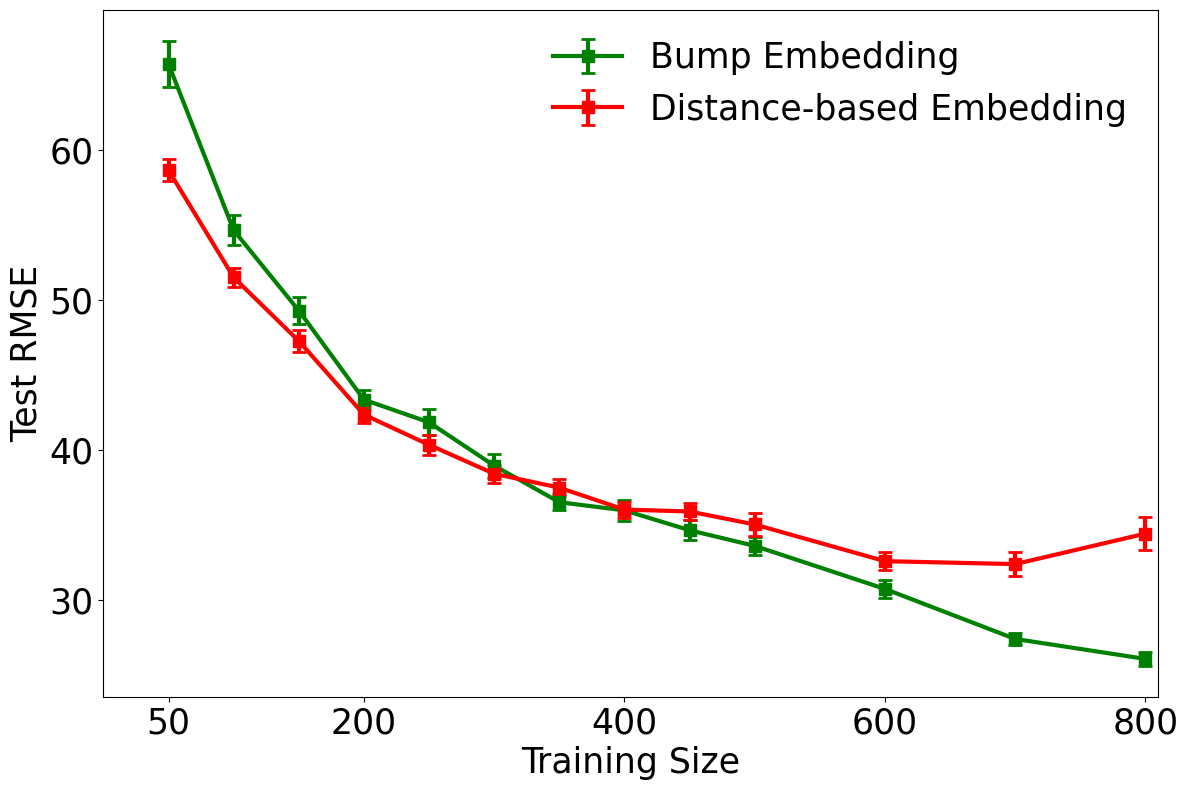

Saved: Ablation_Teddy_Comparison_RMSE.pdf


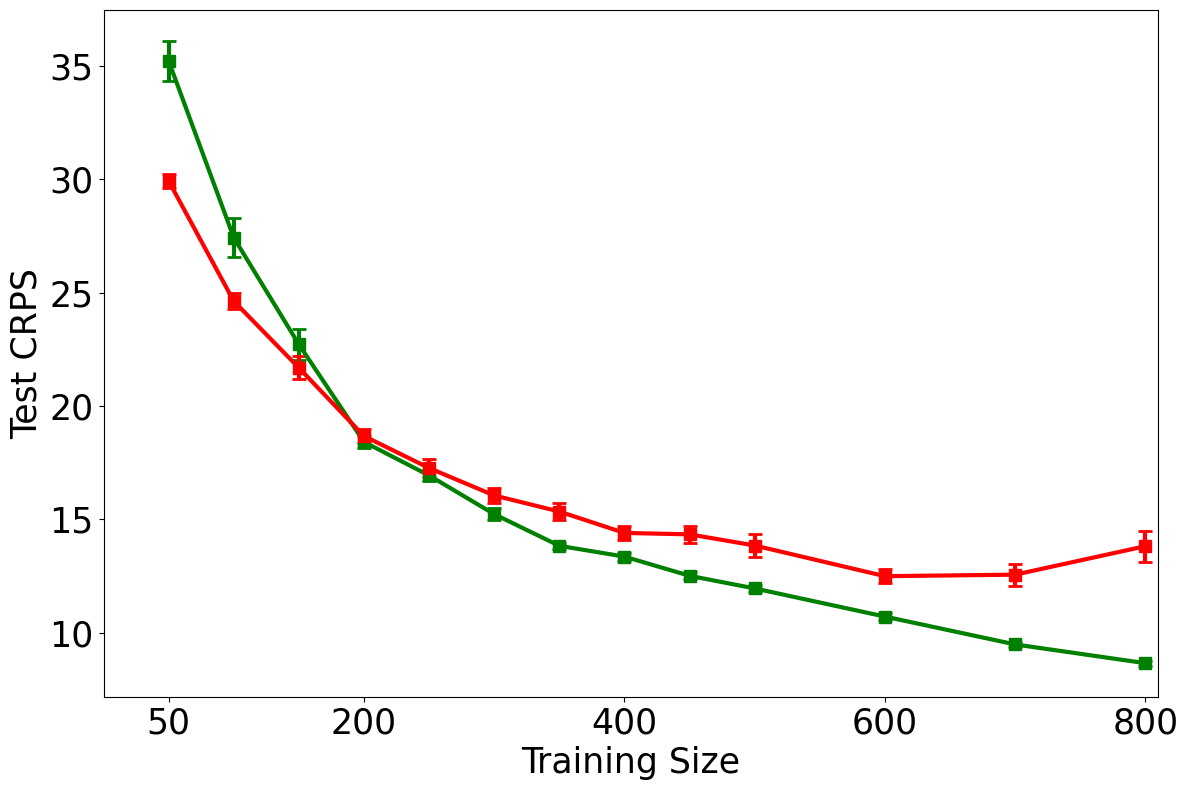

Saved: Ablation_Teddy_Comparison_CRPS.pdf


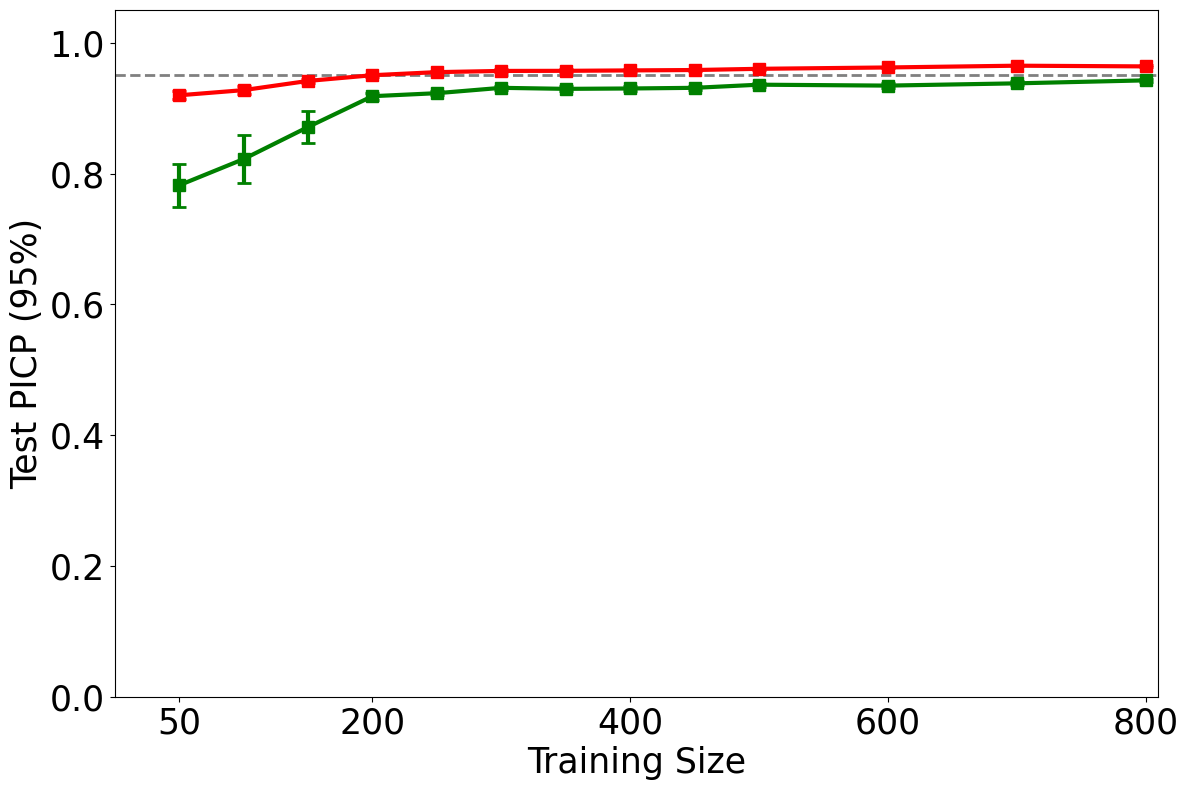

Saved: Ablation_Teddy_Comparison_PICP.pdf


In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
# CONFIGURATION — only edit this section
# ============================================================
files_and_labels = [
    ('teddy_example_gp_experiment_results_Matern_chgAmpl_mcmc5000.json', 'Bump Embedding', 'green'),
    ('teddy_example_gp_experiment_results_Matern_RegularEmbedding_mcmc5000.json', 'Distance-based Embedding', 'red'),
]

# ============================================================
# FUNCTIONS
# ============================================================
def load_and_process_results(filename):
    """Load results and organize by training size"""
    with open(filename, 'r') as f:
        results = json.load(f)
    
    organized = defaultdict(lambda: {
        'train_rmse': [], 
        'test_rmse': [], 
        'test_crps_mean': [], 
        'test_picp': []
    })
    
    for result in results:
        if result.get('status') == 'failed' or 'error' in result:
            continue
        
        train_size = result['training_size']
        organized[train_size]['train_rmse'].append(result['train_rmse'])
        organized[train_size]['test_rmse'].append(result['test_rmse'])
        
        # CRPS and PICP may not exist in older result files
        if 'test_crps mean' in result:
            organized[train_size]['test_crps_mean'].append(result['test_crps mean'])
        if 'test_picp' in result:
            organized[train_size]['test_picp'].append(result['test_picp'])
    
    return organized


def calculate_stats(organized_results, method='iqr'):
    """Calculate mean and standard error for each training size"""
    stats = {}
    
    for train_size, data in organized_results.items():
        test_rmses = np.array(data['test_rmse'])
        
        # Outlier mask based on test RMSE
        q1, q3 = np.percentile(test_rmses, 25), np.percentile(test_rmses, 75)
        iqr = q3 - q1
        mask = (test_rmses >= q1 - 1.5 * iqr) & (test_rmses <= q3 + 1.5 * iqr)
        
        def masked_stats(values):
            arr = np.array(values)
            if len(arr) == 0:
                return np.nan, np.nan
            arr = arr[mask[:len(arr)]]
            return np.mean(arr), np.std(arr) / np.sqrt(len(arr))
        
        train_mean, train_sem = masked_stats(data['train_rmse'])
        test_mean,  test_sem  = masked_stats(data['test_rmse'])
        crps_mean,  crps_sem  = masked_stats(data['test_crps_mean'])
        picp_mean,  picp_sem  = masked_stats(data['test_picp'])
        
        stats[train_size] = {
            'train_mean': train_mean, 'train_sem': train_sem,
            'test_mean':  test_mean,  'test_sem':  test_sem,
            'crps_mean':  crps_mean,  'crps_sem':  crps_sem,
            'picp_mean':  picp_mean,  'picp_sem':  picp_sem,
            'n_trials': int(mask.sum())
        }
    
    return stats

def plot_metric(all_stats, metric_mean, metric_sem, ylabel, title, filename, ylim=None, reference_line=None,add_legened = False,):
    """Generic plotting function"""
    plt.figure(figsize=(12, 8))
    
    for stats, label, color in all_stats:
        train_sizes = sorted(stats.keys())
        means = [stats[s][metric_mean] for s in train_sizes]
        sems  = [stats[s][metric_sem]  for s in train_sizes]
        
        plt.errorbar(train_sizes, means, yerr=sems,
                     marker='s', linewidth=3, capsize=5, capthick=2,
                     label=label, color=color, markersize=8)
    
    # Add reference line if specified
    if reference_line is not None:
        plt.axhline(y=reference_line, color='gray', linestyle='--', 
                    linewidth=2, label=f'{reference_line:.0%} target')
    
    plt.xlabel('Training Size', fontsize=25)
    plt.ylabel(ylabel, fontsize=25)
    if add_legened:
        plt.legend(fontsize=25, frameon=False)    #plt.grid(True, alpha=0.3)
    plt.xlim(0, 810)
    plt.xticks([50, 200, 400, 600, 800], fontsize=25)
    plt.yticks(fontsize=25)
    if ylim:
        plt.ylim(ylim)
    plt.tight_layout()
    plt.savefig(f'/Users/MAlghalayini/Desktop/Postdoc Work/CAMERA gpLVM/Manuscript/Figures/Teddy Bear Results/{filename}', bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


# ============================================================
# LOAD ALL RESULTS
# ============================================================
all_stats = []
for filepath, label, color in files_and_labels:
    results = load_and_process_results(filepath)
    stats   = calculate_stats(results)
    all_stats.append((stats, label, color))
    print(f"✅ Loaded: {label}")

# ============================================================
# PLOT 1 — Test RMSE
# ============================================================
plot_metric(all_stats, 
            metric_mean='test_mean', metric_sem='test_sem',
            ylabel='Test RMSE', title='Test RMSE',
            filename='Ablation_Teddy_Comparison_RMSE.pdf',
            add_legened = True)

# ============================================================
# PLOT 2 — CRPS Mean
# ============================================================
plot_metric(all_stats,
            metric_mean='crps_mean', metric_sem='crps_sem',
            ylabel='Test CRPS', title='Test CRPS',
            filename='Ablation_Teddy_Comparison_CRPS.pdf',
            add_legened = False)

# ============================================================
# PLOT 3 — PICP
# ============================================================
plot_metric(all_stats,
            metric_mean='picp_mean', metric_sem='picp_sem',
            ylabel='Test PICP (95%)', title='Test PICP',
            filename='Ablation_Teddy_Comparison_PICP.pdf',
            ylim=(0, 1.05),
            reference_line=0.95,
            add_legened = False)  # <-- adds the dashed line


In [2]:
train_sizes_of_interest = [ 200, 300,400]
metrics = [
    ('Test RMSE', 'test_mean', 'test_sem'),
    ('Test CRPS', 'crps_mean', 'crps_sem'),
    ('Test PICP', 'picp_mean', 'picp_sem'),
]

for metric_label, mean_key, sem_key in metrics:
    print(f"\n── {metric_label} ──")
    for stats, label, _ in all_stats:
        print(f"  {label}")
        for ts in train_sizes_of_interest:
            if ts in stats:
                mean = stats[ts][mean_key]
                sem  = stats[ts][sem_key]
                print(f"    Training Size {ts}: {mean:.4f} ± {sem:.4f}")
            else:
                print(f"    Training Size {ts}: not found")


── Test RMSE ──
  Geometric Kernel
    Training Size 200: 42.1466 ± 0.3159
    Training Size 300: 36.9648 ± 0.3269
    Training Size 400: 34.0937 ± 0.3384
  SLE (Matern, chg Amp)
    Training Size 200: 41.8254 ± 0.4850
    Training Size 300: 36.7015 ± 0.5580
    Training Size 400: 34.9763 ± 0.5307

── Test CRPS ──
  Geometric Kernel
    Training Size 200: 23.7805 ± 0.2619
    Training Size 300: 18.8048 ± 0.1777
    Training Size 400: 16.1423 ± 0.1534
  SLE (Matern, chg Amp)
    Training Size 200: 18.1335 ± 0.1974
    Training Size 300: 14.6716 ± 0.1825
    Training Size 400: 13.0413 ± 0.1298

── Test PICP ──
  Geometric Kernel
    Training Size 200: 0.1002 ± 0.0030
    Training Size 300: 0.1190 ± 0.0031
    Training Size 400: 0.1377 ± 0.0031
  SLE (Matern, chg Amp)
    Training Size 200: 0.9321 ± 0.0039
    Training Size 300: 0.9412 ± 0.0030
    Training Size 400: 0.9293 ± 0.0028
